Importation des bibliothéques 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 

Chargement du dataset 

In [2]:
df=pd.read_csv("ec2_cpu_utilization_5f5533.csv")
df.head()

,timestamp,value
0,2014-02-14 14:27:00,51.846
1,2014-02-14 14:32:00,44.508
2,2014-02-14 14:37:00,41.244
3,2014-02-14 14:42:00,48.568
4,2014-02-14 14:47:00,46.714


Informations sur les données 

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  4032 non-null   object 
 1   value      4032 non-null   float64
dtypes: float64(1), object(1)
memory usage: 63.1+ KB


,value
count,4032.000000
mean,43.110372
std,4.303565
min,34.766000
25%,39.296000
50%,42.918000
75%,46.006000
max,68.092000


Prétraitement des données 

In [4]:
print ("valeurs nulls: ", df.isnull().sum())
print ("valeurs dupliquées: ", df.duplicated().sum())
df['timestamp']=pd.to_datetime(df['timestamp'])


valeurs nulls:  timestamp    0
value        0
dtype: int64
valeurs dupliquées:  0


Visualisation de la série temporelle 

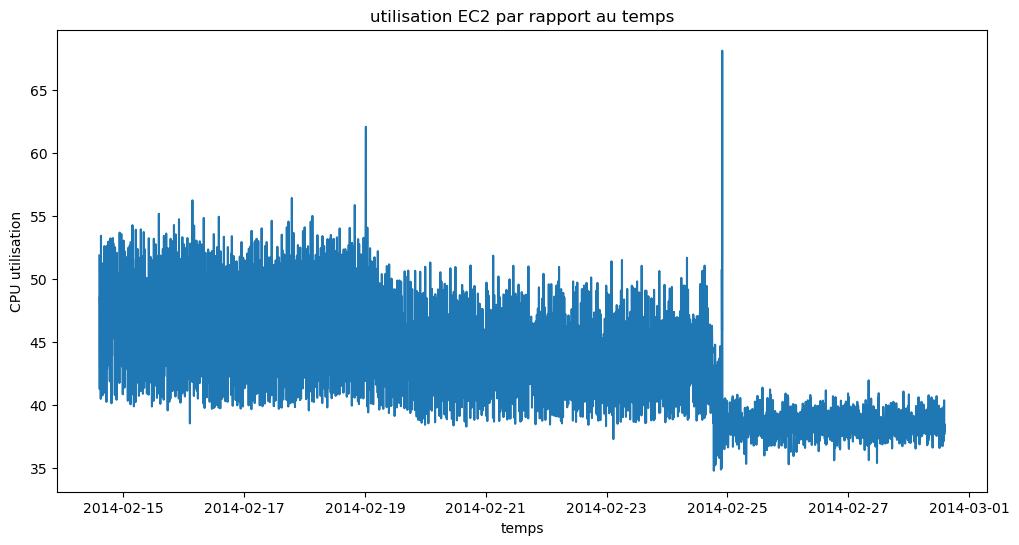

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df['timestamp'],df['value'])
plt.xlabel("temps")
plt.ylabel("CPU utilisation")
plt.title("utilisation EC2 par rapport au temps")
plt.show()

Interprétation : L’utilisation du CPU présente des variations avec des pics indiquant des charges élevées. Une baisse est observée vers la fin du mois de février, suggérant que le système reste actif mais avec une charge réduite, probablement due à une optimisation ou à l’arrêt de certains processus.

Phase 2:Fusion des datasets multi-serveurs 

Importation des bibliothéques : glob pour la recherche des fichiers et os pour manipuler les fichiers 

In [6]:
import glob 
import os 

Lister tous les fichiers CPU

In [7]:
files=glob.glob("realAWSCloudwatch/ec2_cpu_utilization_*.csv")
dfs=[]
for f in files[:5]:
    tdf=pd.read_csv(f)
    tdf['serveur_id']=f.split("_")[-1].replace(".csv","")
    dfs.append(tdf)

Fusion des fichiers 

In [8]:
full_df=pd.concat(dfs)
full_df.head()

,timestamp,value,serveur_id
0,2014-02-14 14:30:00,0.132,24ae8d
1,2014-02-14 14:35:00,0.134,24ae8d
2,2014-02-14 14:40:00,0.134,24ae8d
3,2014-02-14 14:45:00,0.134,24ae8d
4,2014-02-14 14:50:00,0.134,24ae8d


Vérification du dataset 

In [9]:
print(full_df['serveur_id'].shape)
print(full_df['timestamp'].value_counts())
full_df.info()

(20160,)
timestamp
2014-02-14 14:30:00    2
2014-02-23 23:00:00    2
2014-02-23 21:55:00    2
2014-02-23 22:00:00    2
2014-02-23 22:05:00    2
                      ..
2014-04-02 14:30:00    1
2014-04-02 14:35:00    1
2014-04-02 14:40:00    1
2014-04-02 14:45:00    1
2014-04-24 00:09:00    1
Name: count, Length: 16128, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 20160 entries, 0 to 4031
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   timestamp   20160 non-null  object 
 1   value       20160 non-null  float64
 2   serveur_id  20160 non-null  object 
dtypes: float64(1), object(2)
memory usage: 630.0+ KB


Partie A: Fusion des datasets multi-serveurs 
Nous avons fusionné 5 fichiers différents et le dataset résutant contient 32256 lignes et 3 colonnes: 
    -timestamp: l'instant de mesure 
    -value:l'utilisation CPU 
    -serveur_id: l'id du serveur d'origine
Cette fusion des données de plusieurs sources aide à:
    -réduire risque d'overfitting
    -meilleure généralisation
    -tracabilité

In [10]:
full_df['timestamp']=pd.to_datetime(full_df['timestamp'])
full_df.to_csv("cpu_full_dataset.csv", index=False)
